
# EEG Motor Imagery (MI)
1) Configure → 2) Load (EEGBCI or CSV) → 3) Preprocess → 4) Epoch → 5) TFR (Morlet, % change) → 6) ERD metrics → 7) (Optional) CSP+LDA decoding

**Notes**
- Default uses the PhysioNet EEGBCI dataset (left vs right hand MI).
- You can switch to your own CSV (format described below).
- Plots use Matplotlib only.


In [33]:

# %% Imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import mne
import seaborn as sns

from mne.decoding import CSP
from mne.preprocessing import ICA
from mne.stats import permutation_cluster_1samp_test as pcluster_test
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

from autoreject import AutoReject, Ransac

# Make figures a bit larger
plt.rcParams['figure.figsize'] = (9, 4)
mne.set_log_level('WARNING')



## Configure
- `source`: `"eegbci"` or `"csv"`  
- EEGBCI: set `subject` and `runs`  
- CSV: set `csv_path` and (optionally) `channel_cols` and `event_code_map`

**CSV format (expected):**
- Columns: `timestamp` (seconds), `type` (`EEG` or `Marker`), EEG channels (e.g., `ch1...ch16`), `marker` (int codes for events)
- Set `csv_voltage_unit` to `"uV"`, `"mV"`, or `"V"`


In [ ]:

# %% Config
source = "csv"   # "eegbci", "csv", or "ecog_mat"

# EEGBCI settings
subject = 3
runs = [4, 8, 12]  # motor imagery, left vs right

# CSV settings (used if source == "ecog_mat")
# 20250818_121855_1block/20250818_121855_eeg_with_markers_renamed.csv  Simulated_data/simulated_eeg_with_markers_10Hz_ERD_5s.csv
csv_path = r"D:/user/Files_without_backup/MSc_Project/Data/Simulated_data/simulated_eeg_with_markers_10Hz_ERS_5s.csv"   # <- change me
time_col = "timestamp"
type_col = "type"          # values: "EEG" or "Marker"
eeg_value = "EEG"
marker_value = "Marker"
marker_col = "marker"      # integer codes
channel_cols = ["Fp1", "F3", "F7", "C3", "T3", "P3", "T5", "O1", "Fp2", "F4", "F8", "C4", "T4", "P4", "T6", "O2"]        # e.g. [f"ch{i}" for i in range(1,17)]
event_code_map = {21: "left", 22: "right"}  # CSV marker code -> name
csv_voltage_unit = "uV"    # "uV" | "mV" | "V"

# ECoG (.mat) settings (used if source == "ecog_mat")
ecog_mat_path = r"D:/user/Files_without_backup/MSc_Project/Data/data_miller/bp_im_t_h.mat"  # <- change me
ecog_event_id = {'tongue': 11, 'hand': 12}      # default codes in the dataset
ecog_sfreq = 1000.0
ecog_scale_uv = 0.0298   # μV per amplifier unit (per README)

# Preprocessing
notch_freq = 50.0
l_freq, h_freq = 0.5, 40.0
resample_sfreq = None     # set None to keep native
reref = "average"          # "average" or list of ref channel names

# Epoching
tmin, tmax = -1.0, 4.0
baseline = (-1.0, 0.0)


# TFR (Morlet)
freqs = np.arange(2, 36)   # 2–35 Hz
n_cycles = 7.0
baseline_mode = "percent"  # % change: percent, log: logratio

# ERD metrics
mu_band = (8., 13.)
beta_band = (13., 30.)
erd_onset_threshold = -20.0   # % drop (negative)
mi_window = (1.0, 4.0)        # seconds
target_chs = ["C3", "C4"] #, "O1", "O2", "P3", "P4"]

# Output directory
OUT = Path("outputs"); OUT.mkdir(exist_ok=True, parents=True)
print("Configured. Source =", source)


Configured. Source = csv



## Load data
Choose EEGBCI (auto-download via MNE) **or** your own CSV.


In [35]:
# %% ECoG loader
def load_ecog_mat_to_raw(mat_path, event_id=None, sfreq=1000.0, scale_uv=0.0298):
    """
    Load an imagery/movement ECoG .mat (with 'data' and 'stim') into MNE Raw + events.

    Parameters
    ----------
    mat_path : str
        Path to the .mat file (e.g., 'AA_imagery_t_h.mat').
    event_id : dict or None
        Mapping of event names to codes, e.g., {'tongue': 11, 'hand': 12}.
        If None, the mapping is inferred from the codes present.
    sfreq : float
        Sampling frequency in Hz (dataset uses 1000 Hz).
    scale_uv : float
        Microvolts per amplifier unit in the dataset. Convert to Volts for MNE.

    Returns
    -------
    raw : mne.io.RawArray
        ECoG data (channels × samples), ch_type='ecog'.
    events : ndarray, shape (n_events, 3)
        [sample, 0, event_code] for cue onsets.
    event_id : dict
        Name→code mapping.
    """
    from scipy.io import loadmat
    import numpy as np
    import mne

    mat = loadmat(mat_path)
    data = mat['data']           # shape: time × channels
    stim = mat['stim'].ravel()   # shape: time

    # Convert μV to V for MNE
    data_v = (data * scale_uv) / 1e6  # μV → V

    ch_names = [f'E{i+1}' for i in range(data_v.shape[1])]
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='ecog')
    raw = mne.io.RawArray(data_v.T, info)

    # Event onsets = transitions from 0 → non-zero in 'stim'
    stim_bin = (stim != 0).astype(int)
    onsets = (np.diff(stim_bin) == 1).nonzero()[0] + 1
    codes = stim[onsets].astype(int)

    if event_id is None:
        # Infer mapping if not provided
        default_names = {11: 'tongue', 12: 'hand'}
        unique_codes = np.unique(codes)
        event_id = {default_names.get(int(c), f'ev{int(c)}'): int(c) for c in unique_codes}

    events = np.column_stack([onsets, np.zeros_like(onsets), [event_id.get(int(c), int(c)) for c in codes]]).astype(int)
    return raw, events, event_id


In [36]:

# %% Load data
def _to_volts(arr, unit: str):
    u = (unit or '').lower()
    if u in {"uv", "µv"}: return arr / 1e6
    if u in {"mv"}:       return arr / 1e3
    if u in {"v"}:        return arr
    raise ValueError(f"Unknown voltage unit: {unit}")

if source.lower() == "eegbci":
    from mne.datasets import eegbci
    print(f"Fetching EEGBCI s{subject} runs {runs} ...")
    file_paths = eegbci.load_data(subject, runs)
    raws = [mne.io.read_raw_edf(fp, preload=True) for fp in file_paths]
    for r in raws: eegbci.standardize(r)
    raw = mne.concatenate_raws(raws)
    raw.rename_channels(lambda x: x.strip("."))  # remove dots from channel names
    montage = mne.channels.make_standard_montage("standard_1005")
    raw.set_montage(montage, on_missing="ignore")
    events, _ = mne.events_from_annotations(raw, event_id={"T1":1, "T2":2})
    event_id = {"left":1, "right":2}

elif source.lower() == "csv":
    df = pd.read_csv(csv_path, encoding="latin1")
    eeg_df = df[df[type_col] == eeg_value].copy()
    mrk_df = df[df[type_col] == marker_value].copy()
    # channels
    ch_cols = channel_cols
    print(ch_cols)
    if ch_cols is None:
        patt = df.columns.str.match(r"^(ch|eeg)\d+$", case=False)
        ch_cols = [c for c, m in zip(df.columns, patt) if m and c in eeg_df.columns]
        if not ch_cols:
            numeric_cols = [c for c in eeg_df.columns if np.issubdtype(eeg_df[c].dtype, np.number)]
            ch_cols = [c for c in numeric_cols if c != time_col]
    # sampling rate
    eeg_df = eeg_df.sort_values(time_col).drop_duplicates(subset=[time_col])
    ts = eeg_df[time_col].to_numpy()
    sfreq = float(np.round(1.0 / np.median(np.diff(ts))))
    data = eeg_df[ch_cols].to_numpy().T
    data = _to_volts(data, csv_voltage_unit)
    info = mne.create_info(ch_names=ch_cols, sfreq=sfreq, ch_types="eeg")
    raw = mne.io.RawArray(data, info)
    try:
        montage = mne.channels.make_standard_montage("standard_1005")
        raw.set_montage(montage, on_missing="ignore")
    except Exception:
        pass
    # events
    mrk_df = mrk_df.sort_values(time_col)
    names = sorted(set(event_code_map.values()))
    name_to_int = {name: i+1 for i, name in enumerate(names)}
    code_to_int = {code: name_to_int[name] for code, name in event_code_map.items()}
    start_time = eeg_df[time_col].iloc[0]
    events = []
    for t, code in zip(mrk_df[time_col].to_numpy(), mrk_df[marker_col].astype(int).to_numpy()):
        sample = int(np.round((t - start_time) * sfreq))
        if 0 <= sample < raw.n_times and code in code_to_int:
            events.append([sample, 0, code_to_int[code]])
    events = np.array(events, dtype=int)
    event_id = name_to_int

elif source.lower() == "ecog_mat":
    print(f"Loading ECoG .mat: {ecog_mat_path}")
    raw, events, event_id = load_ecog_mat_to_raw(
        ecog_mat_path,
        event_id=ecog_event_id,
        sfreq=ecog_sfreq,
        scale_uv=ecog_scale_uv
    )

else:
    raise ValueError("source must be 'eegbci' or 'csv' or 'ecog_mat'")

print(raw)
print("Events:", len(events), "event_id:", event_id)


['Fp1', 'F3', 'F7', 'C3', 'T3', 'P3', 'T5', 'O1', 'Fp2', 'F4', 'F8', 'C4', 'T4', 'P4', 'T6', 'O2']
<RawArray | 16 x 100000 (200.0 s), ~12.2 MiB, data loaded>
Events: 20 event_id: {'left': 1, 'right': 2}


C:\Users\user\AppData\Local\Temp\ipykernel_31024\1649824968.py:23: DtypeWarning: Columns (19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, encoding="latin1")



## Preprocess 
- Notch 50 Hz, band-pass 0.5–40 Hz, optional resample to 250 Hz, average reference  
- Quick 5 s overlay: raw vs filtered (up to 8 channels; prefer C3/C4/Cz)


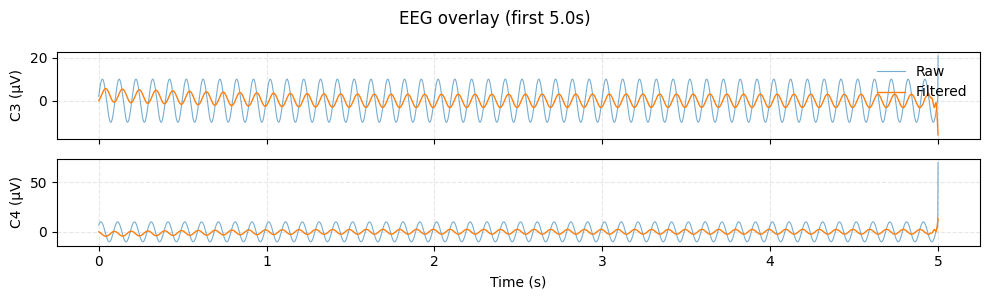

In [37]:

# %% Preprocess + QC
raw_f = raw.copy()
if notch_freq:
    raw_f.notch_filter(freqs=[notch_freq], picks=mne.pick_types(raw_f.info, eeg=True, ecog=True))
if l_freq is not None or h_freq is not None:
    raw_f.filter(l_freq=l_freq, h_freq=h_freq, picks=mne.pick_types(raw_f.info, eeg=True, ecog=True))
if resample_sfreq is not None and resample_sfreq > 0:
    raw_f.resample(resample_sfreq)
# Apply re-referencing only if there are EEG channels:
has_eeg = any(t == 'eeg' for t in raw_f.get_channel_types())
if has_eeg:
    if reref == "average":
        raw_f.set_eeg_reference("average", projection=False)
    elif isinstance(reref, (list, tuple)):
        raw_f.set_eeg_reference(reref, projection=False)

# QC overlay plot (first 5 s)
max_channels = 16
pref = [ch for ch in target_chs if ch in raw.ch_names and ch in raw_f.ch_names]
chs = (pref or raw_f.ch_names)[:max_channels]

r0 = raw.copy()
r1 = raw_f.copy()
if abs(r0.info['sfreq'] - r1.info['sfreq']) > 1e-6:
    r0.resample(r1.info['sfreq'])
win = (0.0, min(5.0, r0.times[-1], r1.times[-1]))
r0.crop(*win); r1.crop(*win)
p0 = mne.pick_channels(r0.ch_names, include=chs)
p1 = mne.pick_channels(r1.ch_names, include=chs)

t = r1.times
dat0 = (r0.get_data(picks=p0) * 1e6)
dat1 = (r1.get_data(picks=p1) * 1e6)

fig, axes = plt.subplots(len(chs), 1, sharex=True, figsize=(10, max(3, len(chs)*1.3)))
if len(chs) == 1: axes = [axes]
for ax, ch, y0, y1 in zip(axes, chs, dat0, dat1):
    ax.plot(t, y0, label="Raw", alpha=0.6, linewidth=0.8)
    ax.plot(t, y1, label="Filtered", linewidth=1.0)
    ax.set_ylabel(f"{ch} (µV)"); ax.grid(True, linestyle="--", alpha=0.3)
axes[0].legend(loc="upper right", frameon=False)
axes[-1].set_xlabel("Time (s)")
plt.suptitle(f"EEG overlay (first {win[1]-win[0]:.1f}s)"); plt.tight_layout()
plt.show()


- weird spikes for csv files

(1000,)


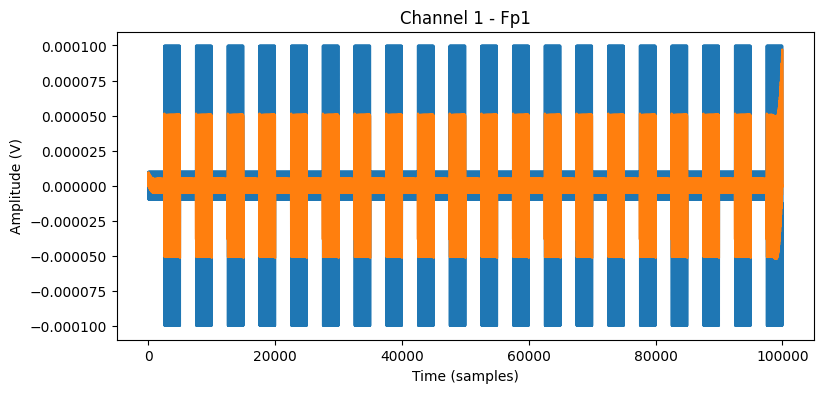

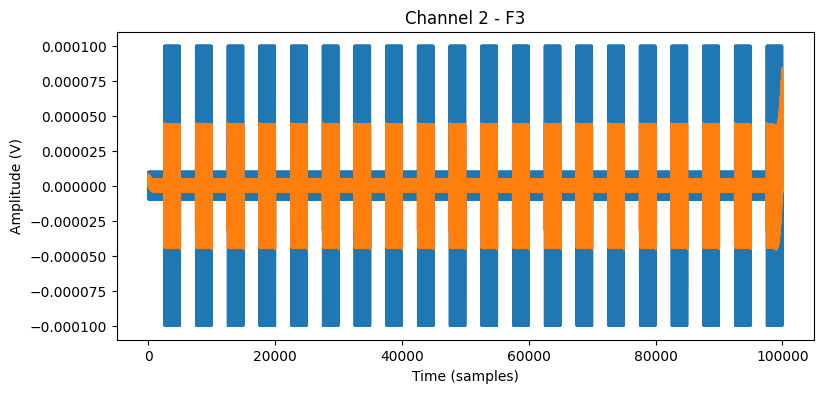

In [38]:
X = raw.get_data(picks=mne.pick_types(raw_f.info, eeg=True, ecog=True))
X_f = raw_f.get_data(picks=mne.pick_types(raw_f.info, eeg=True, ecog=True))
print(X[0][0:1000].shape)
for i in range(2): #(X.shape[0]):
    plt.plot(X[i])
    plt.plot(X_f[i])
    plt.title(f"Channel {i+1} - {raw.ch_names[i]}")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude (V)")
    plt.show()



- ICA

In [39]:
# # 1) Make a copy with a slightly higher high-pass for ICA fitting (helps decomposition)
# ica_hp = 1.0  # Hz
# ica_n_components = 0.99  # keep ~99% variance; or use an int like 20-40
# ica_method = "fastica"   # "picard" or "infomax" also fine if installed
# ica_random_state = 97

# ica_raw = raw.copy().filter(l_freq=ica_hp, h_freq=None, picks=mne.pick_types(raw_f.info, eeg=True, ecog=True))

# # 2) Fit ICA on EEG only
# picks_eeg = mne.pick_types(ica_raw.info, eeg=True, eog=False, meg=False, exclude="bads")
# ica = ICA(n_components=ica_n_components, method=ica_method,
#           max_iter="auto", random_state=ica_random_state)
# ica.fit(ica_raw, picks=picks_eeg, reject_by_annotation=True)

# # 3) Find EOG-related ICs (blinks/eye movements)
# # Prefer real EOG channels if present; otherwise fall back to a frontal EEG channel.
# eog_picks = mne.pick_types(ica_raw.info, eog=True)
# if len(eog_picks) > 0:
#     eog_inds, eog_scores = ica.find_bads_eog(ica_raw)  # auto-detect EOG channel(s)
# else:
#     # try common frontal leads if no explicit EOG channels exist
#     fallback_frontal = next((ch for ch in ("Fp1", "Fp2") if ch in ica_raw.ch_names), None)
#     if fallback_frontal is not None:
#         eog_inds, eog_scores = ica.find_bads_eog(ica_raw, ch_name=fallback_frontal)
#     else:
#         eog_inds, eog_scores = [], []

# # 4) Mark components for exclusion and apply to the already filtered data
# ica.exclude = list(set(ica.exclude).union(eog_inds))
# print(f"ICA excluding components (EOG): {ica.exclude}")

# # inspect before applying (interactive):
# ica.plot_components(); ica.plot_sources(ica_raw)
# ica.plot_properties(ica_raw, picks=ica.exclude)

# ica.apply(raw_f)  # raw_f is now ICA-cleaned


## Epoch around events
Baseline: -1…0 s; Epoch: -1…4 s.


In [40]:

# %% Epoching
picks = mne.pick_types(raw_f.info, eeg=True, ecog=True, exclude='bads')
epochs = mne.Epochs(raw_f, events, event_id=event_id, tmin=tmin - 0.5, tmax=tmax + 0.5,
                    baseline=None, picks=picks, preload=True, detrend=1)
print(epochs)
# epochs.plot(block=False)


<Epochs | 20 events (all good), -1.5 – 4.5 s (baseline off), ~7.4 MiB, data loaded,
 'left': 10
 'right': 10>


AutoReject

[Parallel(n_jobs=24)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Batch computation too fast (0.020445585250854492s.) Setting batch_size=2.
[Parallel(n_jobs=24)]: Done   4 out of  24 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=24)]: Done   7 out of  24 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=24)]: Done  10 out of  24 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=24)]: Done  13 out of  24 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=24)]: Done  16 out of  24 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=24)]: Done  19 out of  24 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=24)]: Done  22 out of  24 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=24)]: Done  24 out of  24 | elapsed:    0.0s finished
[Parallel(n_jobs=24)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Batch computation too fast

[Done]
Running autoreject on ch_type=eeg




Estimated consensus=0.10 and n_interpolate=1
(20, 16) epochs x channels
Dropped 1 / 20 epochs


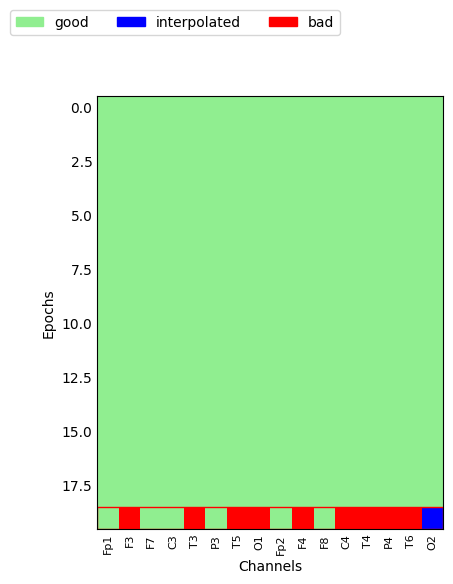

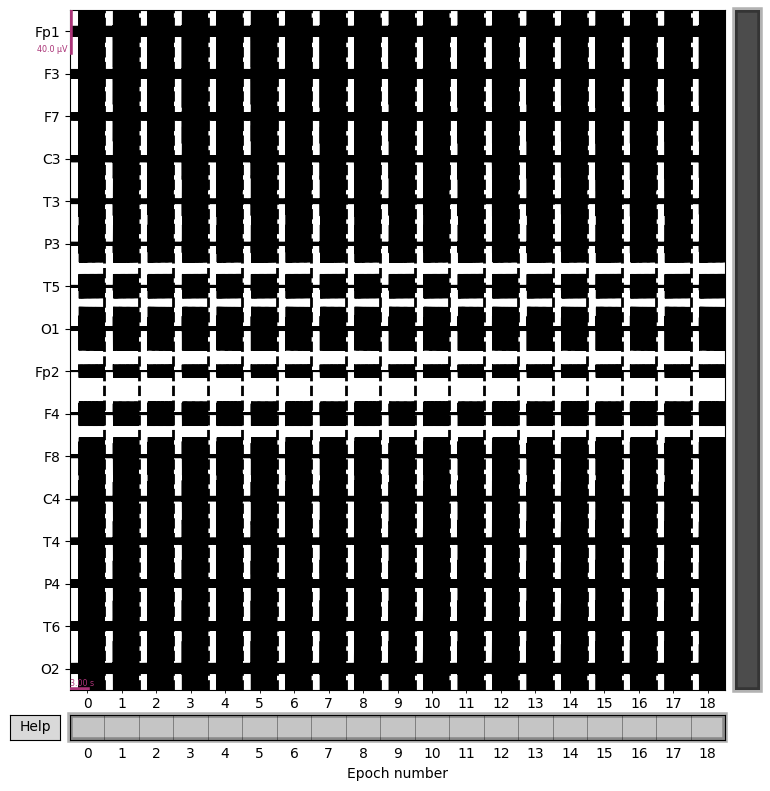

C:\Users\user\AppData\Local\Temp\ipykernel_31024\1573144171.py:26: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  epochs_clean.interpolate_bads()   # should already be clean, but harmless if called


In [41]:
if source.lower() != "ecog_mat":
    # (Optional) RANSAC first: finds consistently bad sensors and interpolates them within epochs
    ransac = Ransac(random_state=97, n_jobs=-1, verbose='tqdm')  # defaults are fine
    epochs_r = ransac.fit_transform(epochs)

    # AutoReject learns thresholds, interpolates bad channels, drops hopeless epochs ---
    ar = AutoReject(
        n_jobs=-1,
        cv=5,                         # cross-validation folds
        random_state=97,
        verbose='tqdm'
        # You can tune these if needed:
        # n_interpolate=[1, 2, 4, 8, 16],              # how many channels can be interpolated per epoch
        # consensus=np.linspace(0.1, 0.6, 6)           # fraction of sensors that must agree a sample is bad
    )
    # epochs_clean
    epochs_clean = ar.fit_transform(epochs_r)       # main step
    reject_log = ar.get_reject_log(epochs_r)        # what got rejected/interpolated

    print(reject_log.labels.shape, "epochs x channels")
    print(f"Dropped {reject_log.bad_epochs.sum()} / {len(epochs_r)} epochs")

    # Optional quick sanity checks:
    reject_log.plot()                 # heatmap of bad channels/epochs
    epochs_clean.plot()               # scroll a few trials
    epochs_clean.interpolate_bads()   # should already be clean, but harmless if called

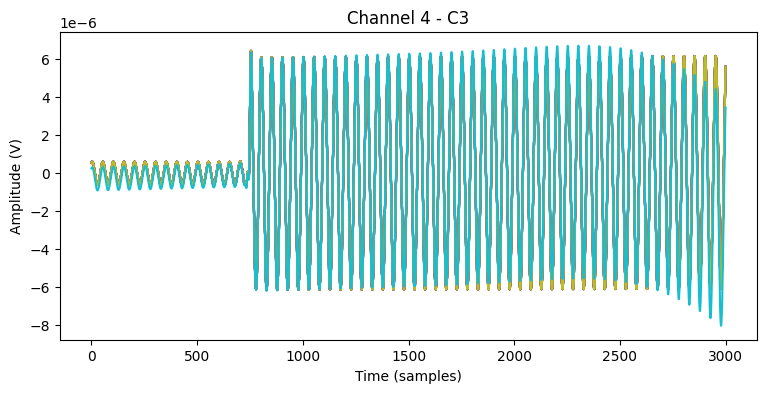

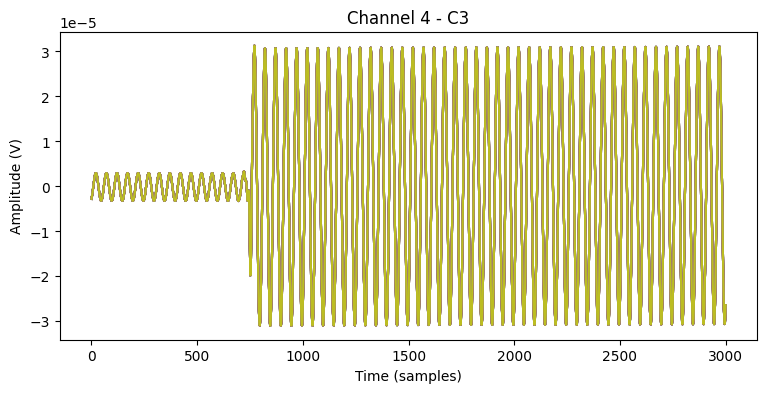

In [42]:
if source.lower() != "ecog_mat":
    X = epochs.get_data(picks=mne.pick_types(raw_f.info, eeg=True, ecog=True))
    X_f = epochs_clean.get_data(picks=mne.pick_types(raw_f.info, eeg=True, ecog=True))
    for i in range(X.shape[0]):
        j = 3
        plt.plot(X[i, 8, :])
        plt.title(f"Channel {j+1} - {raw.ch_names[j]}")
        plt.xlabel("Time (samples)")
        plt.ylabel("Amplitude (V)")
    plt.show()

    for i in range(X_f.shape[0]):
        j = 3
        plt.plot(X_f[i, j, :])
        plt.title(f"Channel {j+1} - {raw.ch_names[j]}")
        plt.xlabel("Time (samples)")
        plt.ylabel("Amplitude (V)")
    plt.show()


In [43]:
epochs = epochs_clean.copy()  # use the cleaned epochs for further processing


## 5) Time–Frequency + baseline (% change)
- ERD = **negative** % change (often blue); ERS = **positive** (often red)  
- Plots below show average across trials.


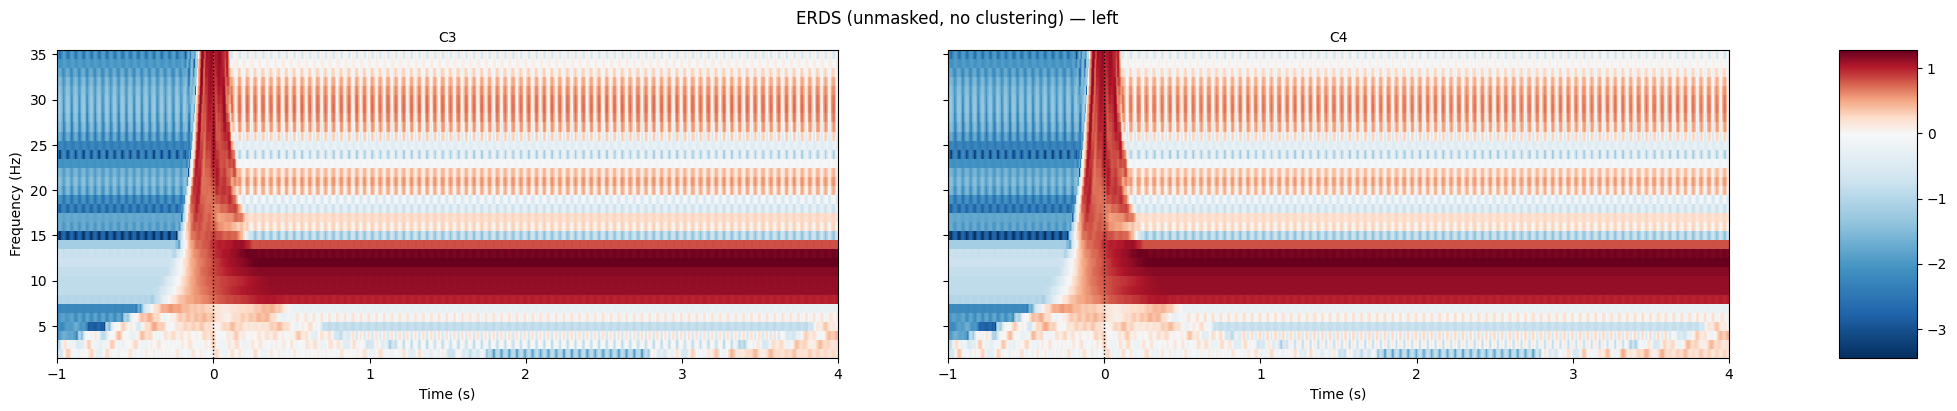

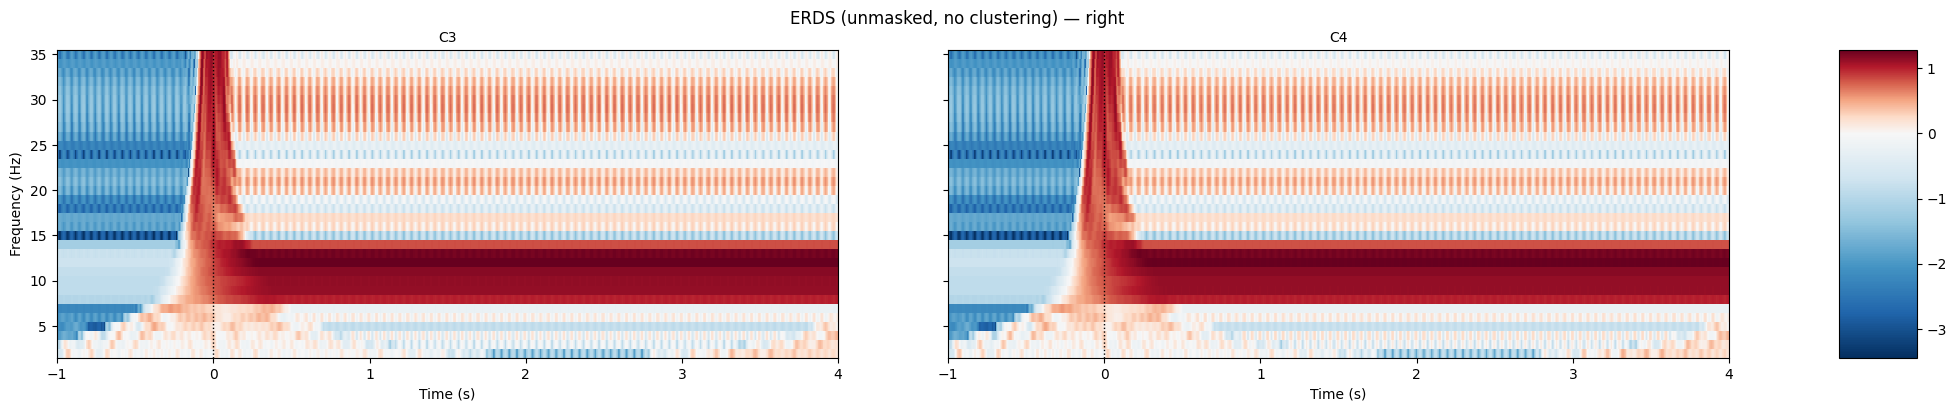

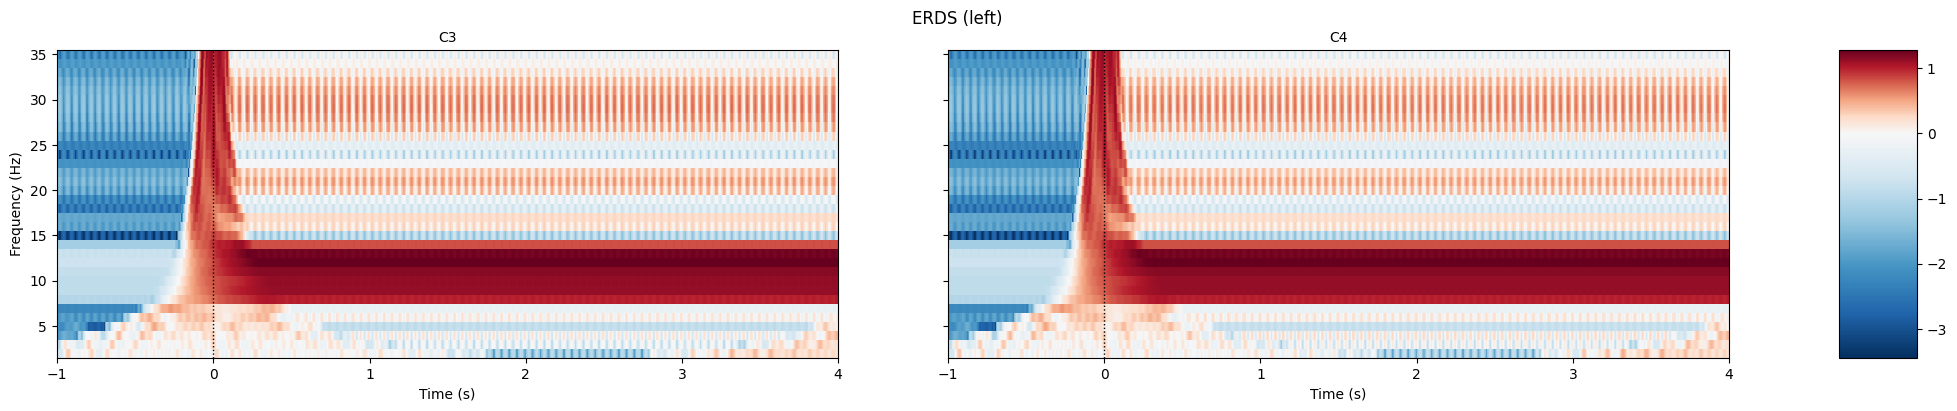

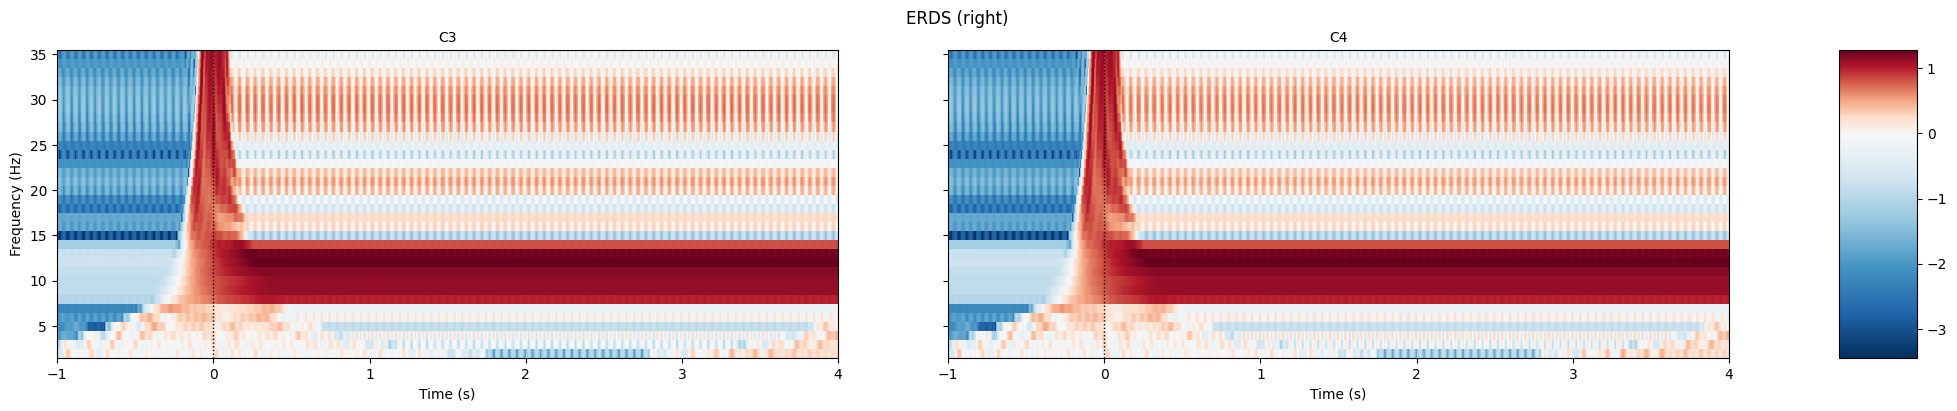

In [44]:
# %% Multitaper/Morlet
method = "multitaper" # "multitaper" or "morlet"

freqs = np.arange(2, 36)  # frequencies from 2-35Hz
# vmin, vmax = -3, 10  # set min and max ERDS values in plot
baseline = (-1, 0)  # baseline interval (in s)
cnorm = TwoSlopeNorm(vcenter=0)  # min, center & max ERDS

kwargs = dict(
    n_permutations=100, step_down_p=0.05, seed=1, buffer_size=None, out_type="mask"
)  # for cluster test

# Compute TFR
tfr = epochs.compute_tfr(method=method, freqs=freqs,
    n_cycles=7, use_fft=True, return_itc=False,
    average=False, decim=2)
tfr.crop(tmin, tmax).apply_baseline(baseline, mode=baseline_mode)

# %% Unmasked Maps (no clustering)
for event in event_id:
    tfr_ev = tfr[event]

    # pick sensorimotor channels (fallback to first 3 if any are missing)
    sel_chs = [ch for ch in target_chs if ch in epochs.ch_names]
    if not sel_chs:
        sel_chs = epochs.ch_names[:3]
    ch_inds = mne.pick_channels(epochs.ch_names, include=sel_chs)

    # precompute condition-average once
    tfr_ev_avg = tfr_ev.average()

    # figure with one panel per selected channel + colorbar
    fig_raw, axes_raw = plt.subplots(
        1, len(ch_inds) + 1, figsize=(24, 4),
        gridspec_kw={"width_ratios": [10] * len(ch_inds) + [1]}
    )

    # plot each channel's full ERDS (no mask)
    for ch_idx, ax in zip(ch_inds, axes_raw[:-1]):
        tfr_ev_avg.plot(
            [ch_idx],
            cmap="RdBu_r",
            cnorm=cnorm,         # same symmetric color scale around 0
            axes=ax,
            colorbar=False,
            show=False,
        )
        ax.set_title(epochs.ch_names[ch_idx], fontsize=10)
        ax.axvline(0, linewidth=1, color="black", linestyle=":")  # event line
        if ch_idx != ch_inds[0]:
            ax.set_ylabel("")
            ax.set_yticklabels([])

    # one shared colorbar
    fig_raw.colorbar(axes_raw[0].images[-1], cax=axes_raw[-1]).ax.set_yscale("linear")
    fig_raw.suptitle(f"ERDS (unmasked, no clustering) — {event}")
    plt.show()


# %% Cluster-based ERDS Maps
for event in event_id:
    # select desired epochs for visualization
    tfr_ev = tfr[event]
    
    # pick sensorimotor channels (fallback to first 3 if any are missing)
    sel_chs = [ch for ch in target_chs if ch in epochs.ch_names]

    if not sel_chs:
        sel_chs = epochs.ch_names[:3]
    ch_inds = mne.pick_channels(epochs.ch_names, include=sel_chs)

    # figure with one panel per selected channel + colorbar
    fig, axes = plt.subplots(
        1, len(ch_inds) + 1, figsize=(24, 4),
        gridspec_kw={"width_ratios": [10] * len(ch_inds) + [1]}
    )

    for ch_idx, ax in zip(ch_inds, axes[:-1]):
        # positive clusters
        _, c1, p1, _ = pcluster_test(tfr_ev.data[:, ch_idx], tail=1, **kwargs)
        # negative clusters
        _, c2, p2, _ = pcluster_test(tfr_ev.data[:, ch_idx], tail=-1, **kwargs)

        # note that we keep clusters with p <= 0.05 from the combined clusters
        # of two independent tests; in this example, we do not correct for
        # these two comparisons
        c = np.stack(c1 + c2, axis=2)  # combined clusters
        p = np.concatenate((p1, p2))  # combined p-values
        mask = c[..., p <= 0.05].any(axis=-1)

        # plot TFR (ERDS map with masking)
        tfr_ev.average().plot(
            [ch_idx],
            cmap="RdBu_r",
            cnorm=cnorm,
            axes=ax,
            colorbar=False,
            show=False,
            mask=mask,
            mask_style="mask",
        )

        ax.set_title(epochs.ch_names[ch_idx], fontsize=10)
        ax.axvline(0, linewidth=1, color="black", linestyle=":")  # event
        if ch_idx != ch_inds[0]:
            ax.set_ylabel("")
            ax.set_yticklabels("")

    fig.colorbar(axes[0].images[-1], cax=axes[-1]).ax.set_yscale("linear")
    fig.suptitle(f"ERDS ({event})")
    plt.show()

<Axes: >

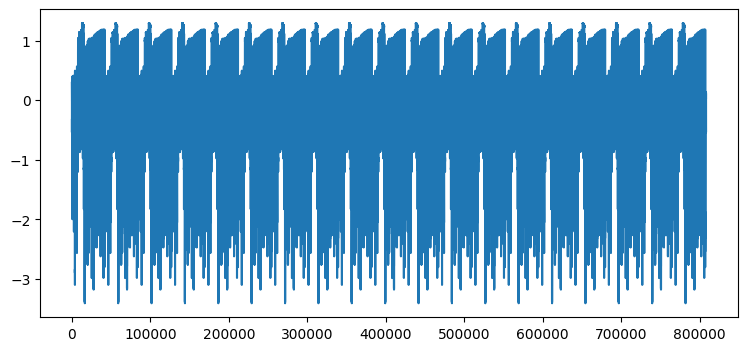

In [45]:
df = tfr.to_data_frame(time_format=None)
df.head()
df["O1"].plot()

In [46]:
df_all_chs = tfr.to_data_frame(time_format=None, long_format=True)
df_target_chs = df_all_chs[df_all_chs["channel"].isin(target_chs)].copy()

# Map to frequency bands:
freq_bounds = {"_": 0, "delta": 3, "theta": 7, "alpha": 13, "beta": 35, "gamma": 140}
df_target_chs["band"] = pd.cut(
    df_target_chs["freq"], list(freq_bounds.values()), labels=list(freq_bounds)[1:]
)

# Filter to retain only relevant frequency bands:
freq_bands_of_interest = ["delta", "theta", "alpha", "beta"]
df_target_chs = df_target_chs[df_target_chs.band.isin(freq_bands_of_interest)]
df_target_chs["band"] = df_target_chs["band"].cat.remove_unused_categories()



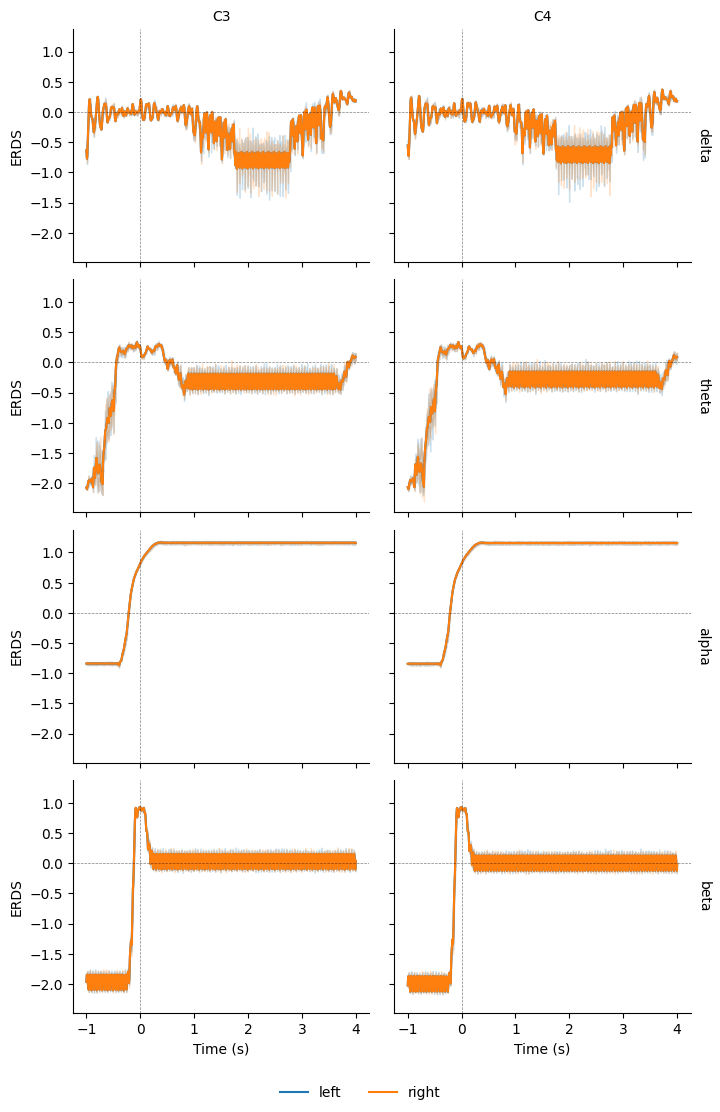

In [47]:
# Order channels for plotting:
df_target_chs["channel"] = pd.Categorical(df_target_chs["channel"], categories=target_chs, ordered=True)

g = sns.FacetGrid(df_target_chs, row="band", col="channel", margin_titles=True)
g.map(sns.lineplot, "time", "value", "condition", n_boot=10)
axline_kw = dict(color="black", linestyle="dashed", linewidth=0.5, alpha=0.5)
g.map(plt.axhline, y=0, **axline_kw)
g.map(plt.axvline, x=0, **axline_kw)
# g.set(ylim=(None, 1.5))
g.set_axis_labels("Time (s)", "ERDS")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.add_legend(ncol=2, loc="lower center")
g.fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.08)


## 7) Decoding (CSP + LDA)
5-fold CV accuracy on MI window (8–30 Hz).  
Skip if you don't need it.


In [48]:

# %% Optional decoding
try:
    ep = epochs.copy().crop(*mi_window).load_data().filter(8., 30., picks='eeg')
    X = ep.get_data()              # (n_epochs, n_channels, n_times)
    y = ep.events[:, 2]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pipe = Pipeline([('csp', CSP(n_components=6, reg='oas', log=True, norm_trace=False)),
                     ('lda', LDA())])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    print(f"Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")
except Exception as e:
    print("Decoding skipped:", e)


Accuracy: 0.300 ± 0.292
